In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data.csv')  # adjust filename to match your download
df.head()

print(df.columns.tolist())


['case', 'sex', 'age', 'sec', 'min', 'hour', 'date', 'month', 'year', 'country', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22', 'i23', 'i24', 'i25', 'i26', 'i27', 'i28', 'i29', 'i30', 'i31', 'i32', 'i33', 'i34', 'i35', 'i36', 'i37', 'i38', 'i39', 'i40', 'i41', 'i42', 'i43', 'i44', 'i45', 'i46', 'i47', 'i48', 'i49', 'i50', 'i51', 'i52', 'i53', 'i54', 'i55', 'i56', 'i57', 'i58', 'i59', 'i60', 'i61', 'i62', 'i63', 'i64', 'i65', 'i66', 'i67', 'i68', 'i69', 'i70', 'i71', 'i72', 'i73', 'i74', 'i75', 'i76', 'i77', 'i78', 'i79', 'i80', 'i81', 'i82', 'i83', 'i84', 'i85', 'i86', 'i87', 'i88', 'i89', 'i90', 'i91', 'i92', 'i93', 'i94', 'i95', 'i96', 'i97', 'i98', 'i99', 'i100', 'i101', 'i102', 'i103', 'i104', 'i105', 'i106', 'i107', 'i108', 'i109', 'i110', 'i111', 'i112', 'i113', 'i114', 'i115', 'i116', 'i117', 'i118', 'i119', 'i120', 'i121', 'i122', 'i123', 'i124', 'i125', 'i126', 'i127', 'i128', 'i1

In [8]:
# Big Five question groupings

O_items = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
C_items = [3, 8, 13, 18, 23, 28, 33, 38, 43, 48]
E_items = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
A_items = [2, 7, 12, 17, 22, 27, 32, 37, 42, 47]
N_items = [4, 9, 14, 19, 24, 29, 34, 39, 44, 49]

In [9]:
O_cols = [f"i{i}" for i in O_items]
C_cols = [f"i{i}" for i in C_items]
E_cols = [f"i{i}" for i in E_items]
A_cols = [f"i{i}" for i in A_items]
N_cols = [f"i{i}" for i in N_items]

In [10]:
df["O"] = df[O_cols].mean(axis=1)
df["C"] = df[C_cols].mean(axis=1)
df["E"] = df[E_cols].mean(axis=1)
df["A"] = df[A_cols].mean(axis=1)
df["N"] = df[N_cols].mean(axis=1)

In [11]:
ocean_cols = ["O", "C", "E", "A", "N"]

df_ocean = df[ocean_cols].dropna()

df_ocean.head()

,O,C,E,A,N
0,4.5,4.3,1.1,3.9,4.2
1,3.3,3.3,2.6,3.8,3.1
2,3.3,4.1,2.5,2.6,3.8
3,4.2,2.8,3.9,2.6,4.5
4,4.1,3.9,3.9,3.4,3.8


In [12]:
df_ocean.describe()

,O,C,E,A,N
count,145388.000000,145388.000000,145388.000000,145388.000000,145388.000000
mean,3.704434,3.883901,3.024962,3.382598,3.497427
std,0.589159,0.499457,0.770309,0.723383,0.512430
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.300000,3.600000,2.500000,2.900000,3.200000
50%,3.700000,3.900000,3.000000,3.400000,3.500000
75%,4.100000,4.200000,3.600000,3.900000,3.900000
max,5.000000,5.000000,5.000000,5.000000,5.000000


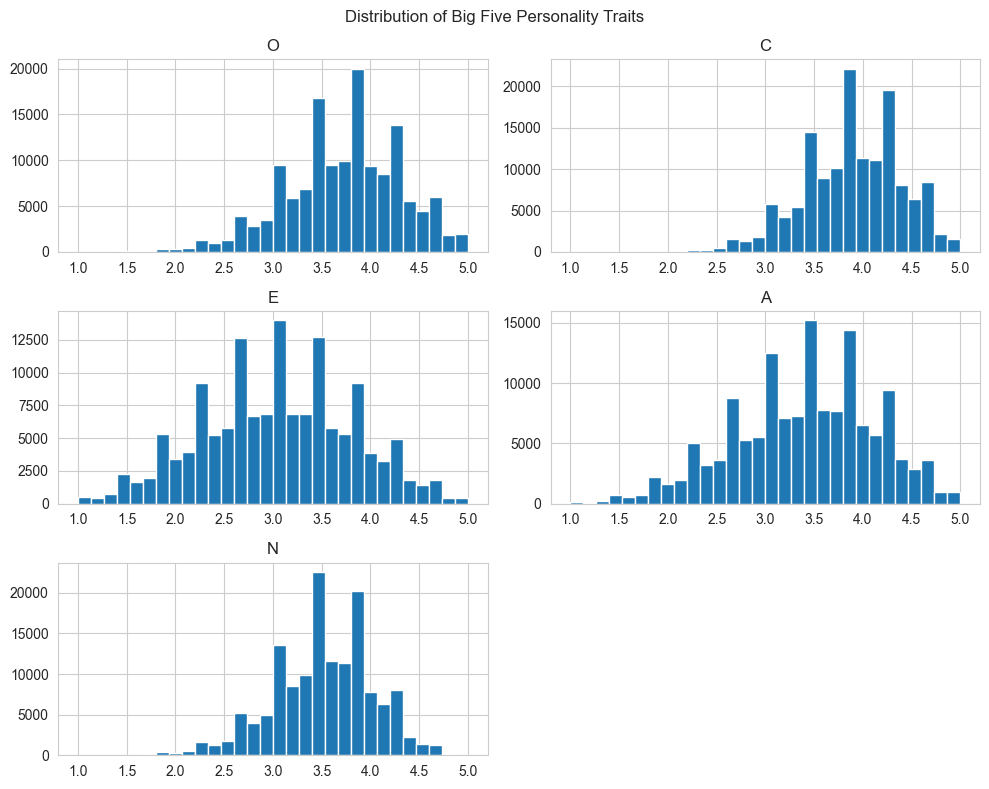

In [13]:
# Check distributions of personality traits

df_ocean.hist(figsize=(10, 8), bins=30)

plt.suptitle("Distribution of Big Five Personality Traits")

plt.tight_layout()
plt.show()

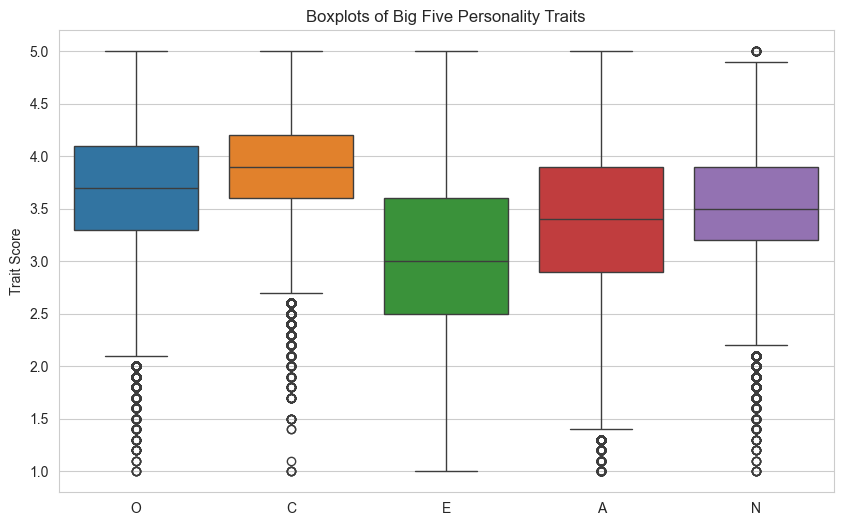

In [14]:
# Boxplots for outliers/spread

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_ocean)

plt.title("Boxplots of Big Five Personality Traits")
plt.ylabel("Trait Score")

plt.show()

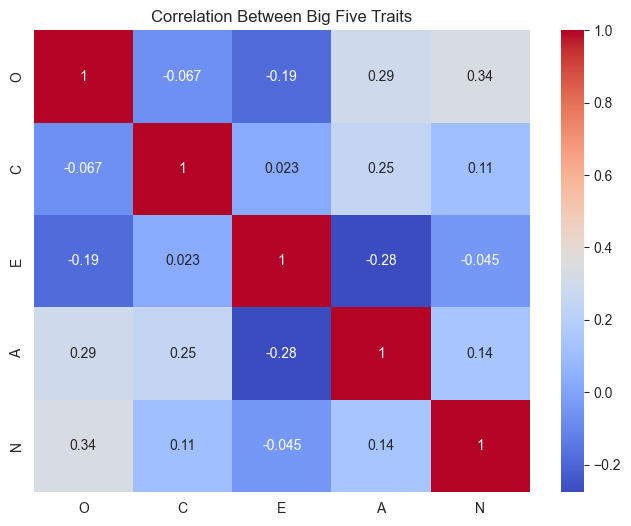

In [15]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_ocean.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Big Five Traits")

plt.show()

In [ ]:
# Normalize to 0-1 or standardize — important before K-means
scaler = StandardScaler()
X = scaler.fit_transform(df_ocean)
# Elbow method to pick number of clusters
inertias = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()